In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from smt.sampling_methods import LHS


import os
import sys

# Changing directory to FEWNEW/work
# to import stuffs
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike_timemax  # TIME-MAXIMIZED VERSION
# import modeselectoralt
import parismc
# import gc
import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 3/12     # Total time
print(f"Using dt = {dt} seconds, T = {T} years")

print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": force_backend # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": force_backend,  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs_comb = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

# Kerr eccentric flux
waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)


print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs.GravWaveAnalysis(T, dt)

print("Initializing loglike class...")


# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 1.8  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

# n-indexed mode selection parameters
n_vals = np.arange(-1,6)  # n from -1 to 5
ell = 2  # quadrupole only

# NOTE: change verbose argument for debugging
# Using n-indexed mode selection
loglike_obj = loglike_timemax.LogLikeTimeMax(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None  # No SNR filtering, use all n-groups
)

print('Done initializing loglike class.')
print('Calculating SNR...')
data = loglike_obj.signal
data_snr = gwf.rhostat(data)
print('SNR calculated:', data_snr)
print("Setting up log_density and prior functions...")


def log_density(params):
    params = np.asarray(params)

    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)


    for i in range(n_samples):
        logm1, logm2, a, p0, e0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2

        loglike = loglike_obj(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
        log_likes[i] = loglike #NOTE: scaled 10x

    return log_likes

def prior_transform(u):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8,1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]

    transformed = np.zeros_like(u)

    # Uniform in log for masses

    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]

    # Linear in others 

    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]

    # p0
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0] 

    # e0
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]

    
    return transformed

    

print('Done setting up log-likelihood and prior.')

Using dt = 10 seconds, T = 0.25 years
Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Creating GravWaveAnalysis class...
Initializing loglike class...
Done initializing loglike class.
Calculating SNR...
SNR calculated: 5.942134448355127
Setting up log_density and prior functions...
Done setting up log-likelihood and prior.


In [4]:
log_density([param_true])

array([5.90712146])

In [29]:
# Load LHS best point                                                                                                                                                              
with open('/scratch/e1498138/lhs/lhs_snr32_1e5.pkl', 'rb') as f:                                                                                         
    _phys_pts_1e5, _logden_1e5 = pickle.load(f)                                                                                                                                            
lhs_1e5 = _phys_pts_1e5[np.argmax(_logden_1e5)]   

with open('/scratch/e1498138/lhs/lhs_snr32_1e4.pkl', 'rb') as f:                                                                                         
    _phys_pts_1e4, _logden_1e4 = pickle.load(f)                                                                                                                                            
lhs_1e4 = _phys_pts_1e4[np.argmax(_logden_1e4)]  


with open('/scratch/e1498138/lhs/lhs_snr32_1e6.pkl', 'rb') as f:                                                                                         
    _phys_pts_1e6, _logden_1e6 = pickle.load(f)                                                                                                                                            
lhs_1e6 = _phys_pts_1e6[np.argmax(_logden_1e6)]  

with open('/nfs/home/svu/e1498138/localgit/FEWNEW/work/search/study/parisinit_1e5_lhs_1.pkl', 'rb') as f:                                                                                         
    _phys_pts_1e5_1, _logden_1e5_1 = pickle.load(f)                                                                                                                                            
lhs_1e5_1 = _phys_pts_1e5_1[np.argmax(_logden_1e5_1)]  

with open('/nfs/home/svu/e1498138/localgit/FEWNEW/work/search/study/parisinit_1e5_lhs_2.pkl', 'rb') as f:                                                                                         
    _phys_pts_1e5_2, _logden_1e5_2 = pickle.load(f)                                                                                                                                            
lhs_1e5_2 = _phys_pts_1e5_2[np.argmax(_logden_1e5_2)] 

In [7]:
lhs_1e5

array([6.027908  , 1.0292175 , 0.77857365, 8.652845  , 0.3800045 ])

In [30]:
lhs_maxld_1e5 = np.max(_logden_1e5)
print(lhs_maxld_1e5)

lhs_maxld_1e4 = np.max(_logden_1e4)
print(lhs_maxld_1e4)

lhs_maxld_1e6 = np.max(_logden_1e6)
print(lhs_maxld_1e6)

lhs_maxld_1e5_1 = np.max(_logden_1e5_1)
print(lhs_maxld_1e5_1)

lhs_maxld_1e5_2 = np.max(_logden_1e5_2)
print(lhs_maxld_1e5_2)

1.7004031123105303
1.3865707956455993
2.888106988363118
1.9911894345570982
1.9887103811064917


# all 5 lhs

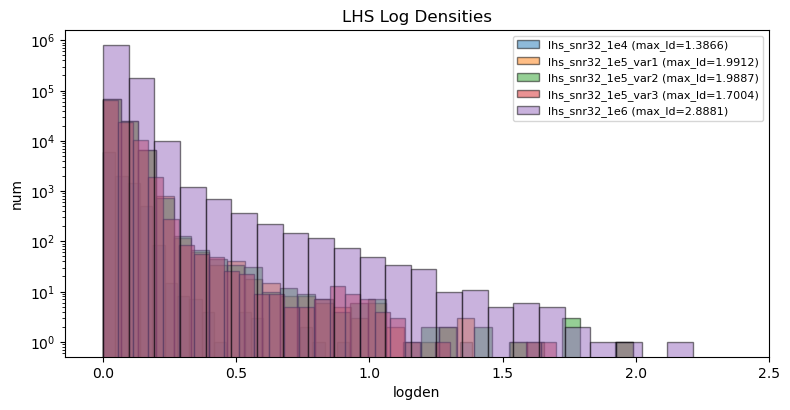

In [31]:
# bins = [0, 0.25, 0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 2.00,                                                                                                                         
#         2.25, 2.50, 2.75, 3.00, 3.25, 3.50, 3.75, 4.00,                                                                                                                            
#         4.25, 4.50, 4.75, 5.00]                                                                                                                                                    
                                                                                                                                                                                    
datasets = {}                                                                                                                                                                      
                                                                                                                                                                                    
datasets['lhs_snr32_1e4'] = _logden_1e4                                                                                                                                
datasets['lhs_snr32_1e5_var1'] = _logden_1e5_1   
datasets['lhs_snr32_1e5_var2'] = _logden_1e5_2                                                                                                                                                     
datasets['lhs_snr32_1e5_var3'] = _logden_1e5                                                                                                                                                                                                                                                                                                          
datasets['lhs_snr32_1e6'] = _logden_1e6 

fig, ax = plt.subplots(figsize=(8, 4))                                                                                                                                             
                                                                                                                                                                                   
for name, ld in datasets.items():                                                                                                                                                  
    ax.hist(ld, bins=30, edgecolor='black', alpha=0.5, label=f'{name} (max_ld={ld.max():.4f})')                                                                                     
                                                                                                                                                                                    
ax.set_yscale('log')                                                                                                                                                             
ax.set_xlabel('logden')                                                                                                                                                       
ax.set_ylabel('num')                                                                                                                                                             
ax.legend(fontsize=8)
plt.xlim(None,2.5)
plt.tight_layout()      
plt.title('LHS Log Densities')                                                                                                                                                           
# plt.savefig('logden_histograms.png', dpi=150)
plt.show()    

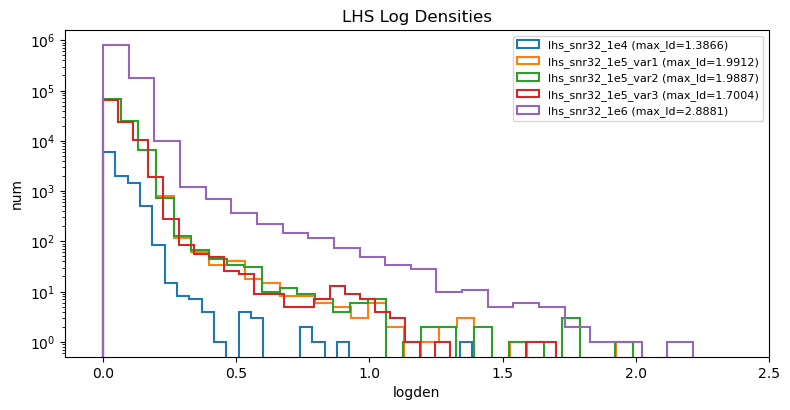

In [32]:
fig, ax = plt.subplots(figsize=(8, 4))

for name, ld in datasets.items():
    ax.hist(ld, bins=30, histtype='step', linewidth=1.5,
            label=f'{name} (max_ld={ld.max():.4f})')

ax.set_yscale('log')
ax.set_xlabel('logden')
ax.set_ylabel('num')
ax.legend(fontsize=8)
plt.xlim(None, 2.5)
plt.tight_layout()
plt.title('LHS Log Densities')
plt.show()

In [33]:
ranges = [                                                                                                                                                                         
    (5.6, 6.4),                                                                                                                                                                    
    (0.8, 1.3),                                                                                                                                                                    
    (0.3, 0.99),                                                                                                                                                                   
    (8.0, 11.0),                                                                                                                                                                 
    (0.2, 0.5),
]       
labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$']                                                                                                        


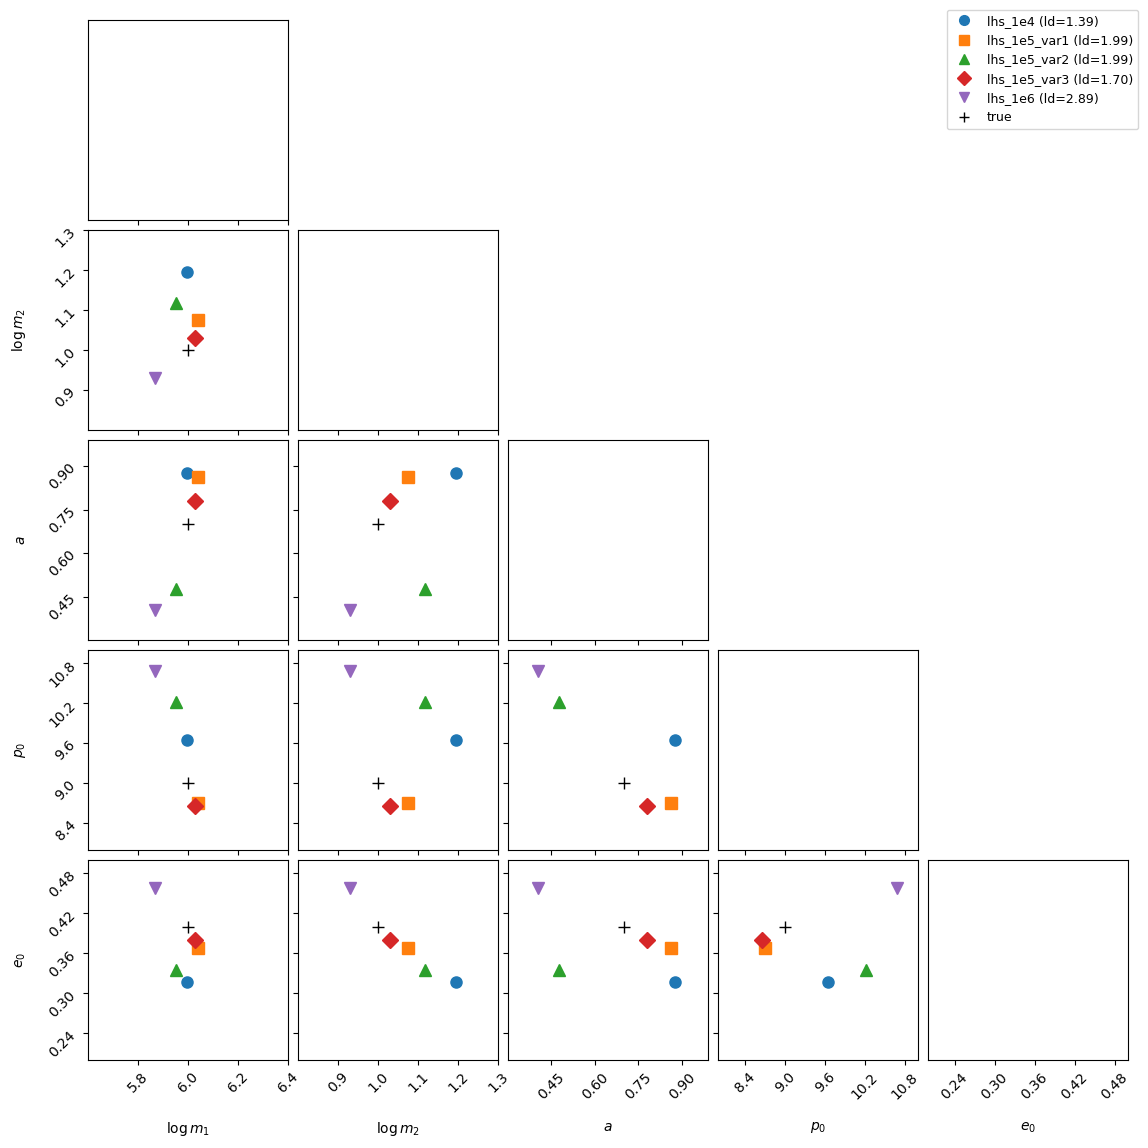

In [36]:
import corner
ndim=5
plot_points = {
    'lhs_1e4': lhs_1e4,
    'lhs_1e5_var1': lhs_1e5_1,
    'lhs_1e5_var2': lhs_1e5_2,
    'lhs_1e5_var3': lhs_1e5,
    'lhs_1e6': lhs_1e6,
    'true':    np.array(param_true),
}
colors  = ['C0', 'C1', 'C2', 'C3', 'C4', 'black']
markers = ['o',  's',  '^',  'D',  'v',  '+']
mlds    = [np.max(_logden_1e4), np.max(_logden_1e5_1), np.max(_logden_1e5_2),
           np.max(_logden_1e5), np.max(_logden_1e6), None]

lo = np.array([r[0] for r in ranges])
hi = np.array([r[1] for r in ranges])
all_pts_padded = np.vstack([np.array(list(plot_points.values())), lo, hi])

fig = corner.corner(all_pts_padded, labels=labels, show_titles=False,
                    plot_datapoints=False, plot_density=False,
                    plot_contours=False, ranges=ranges,
                    hist_kwargs=dict(alpha=0))

for (name, pt), c, mk in zip(plot_points.items(), colors, markers):
    corner.overplot_points(fig, pt.reshape(1, -1), color=c, marker=mk, ms=8)

axes = np.array(fig.axes).reshape((ndim, ndim))
for row in range(ndim):
    for col in range(ndim):
        if col <= row:
            axes[row, col].set_xlim(ranges[col])
        if col < row:
            axes[row, col].set_ylim(ranges[row])

from matplotlib.lines import Line2D
handles = [Line2D([0],[0], color=c, marker=mk, ls='', ms=7,
                  label=f"{name} (ld={ld:.2f})" if ld else name)
           for (name, _), c, mk, ld in zip(plot_points.items(), colors, markers, mlds)]
fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=9)
plt.show()